In [30]:
import torch
import torch.nn as nn
import math
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from datasets import load_dataset
from torchvision.datasets import ImageFolder
from PIL import Image
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de : {device}")

Utilisation de : cuda


In [31]:
BATCH_SIZE = 32
SEED = 0
def apply_transforms(examples):   
    # On applique la transformation à chaque image du batch
    examples["pixel_values"] = [transform(img.convert("RGB")) for img in examples["image"]]
    return examples

In [32]:
import torch
from collections import Counter

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def dataset_targets(ds):
    """Retourne la liste des labels (int) d'un Dataset ou Subset(random_split)."""
    if hasattr(ds, "targets"):  # ImageFolder
        return list(ds.targets)
    if hasattr(ds, "dataset") and hasattr(ds, "indices"):  # Subset
        base_targets = ds.dataset.targets
        return [base_targets[i] for i in ds.indices]
    raise TypeError(f"Unsupported dataset type: {type(ds)}")

def print_dataset_report(name, full_ds, train_ds, val_ds, test_ds, train_loader, val_loader, test_loader):
    print("\n" + "="*80)
    print(f"DATASET REPORT — {name}")
    print("="*80)

    # Infos globales
    print(f"Root dataset type: {type(full_ds).__name__}")
    print(f"Num classes: {len(full_ds.classes)}")
    print("Classes:", full_ds.classes)
    print(f"Total images: {len(full_ds)}")
    print(f"Split sizes: train={len(train_ds)} | val={len(val_ds)} | test={len(test_ds)}")

    # Distribution classes
    tr = Counter(dataset_targets(train_ds))
    va = Counter(dataset_targets(val_ds))
    te = Counter(dataset_targets(test_ds))

    # mapping idx->class
    idx2class = {i: c for i, c in enumerate(full_ds.classes)}

    def fmt(counter, top_k=None):
        items = [(idx2class[k], v) for k, v in counter.items()]
        items.sort(key=lambda x: (-x[1], x[0]))
        if top_k is not None:
            items = items[:top_k]
        return ", ".join([f"{c}:{v}" for c, v in items])

    print("\nClass distribution (counts):")
    print("  Train:", fmt(tr))
    print("  Val  :", fmt(va))
    print("  Test :", fmt(te))

    # Exemple batch
    xb, yb = next(iter(train_loader))
    print("\nOne train batch:")
    print(f"  images: shape={tuple(xb.shape)} dtype={xb.dtype} min={xb.min().item():.3f} max={xb.max().item():.3f}")
    print(f"  labels: shape={tuple(yb.shape)} dtype={yb.dtype} min={yb.min().item()} max={yb.max().item()}")
    print(f"  expected label range: 0..{len(full_ds.classes)-1}")

    # DataLoader params utiles
    print("\nDataloaders:")
    print(f"  batch_size={train_loader.batch_size} | num_workers={train_loader.num_workers} | pin_memory={train_loader.pin_memory}")
    print(f"  train batches/epoch={len(train_loader)} | val batches={len(val_loader)} | test batches={len(test_loader)}")


# Vehicles


In [64]:
# Chemin vers dossier local
DATA_DIR_V = "Vehicles" 
IMG_SIZE_V = 128

# Transforms
transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((IMG_SIZE_V, IMG_SIZE_V)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

# Dataset local (classe = nom du sous-dossier)
full_ds_v = ImageFolder(root=DATA_DIR_V, transform=transform)
NUM_CLASSES_V = len(full_ds_v.classes)

# Classes
#print("Classes:", full_ds_v.classes)
#print("NUM_CLASSES:", NUM_CLASSES_V)

# Split 80/10/10
torch.manual_seed(SEED)
n = len(full_ds_v)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val

train_ds_v, val_ds_v, test_ds_v = random_split(full_ds_v, [n_train, n_val, n_test])

train_loader_v = DataLoader(train_ds_v, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader_v   = DataLoader(val_ds_v, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader_v  = DataLoader(test_ds_v, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

In [65]:
print_dataset_report(
    name="Vehicles",
    full_ds=full_ds_v,
    train_ds=train_ds_v,
    val_ds=val_ds_v,
    test_ds=test_ds_v,
    train_loader=train_loader_v,
    val_loader=val_loader_v,
    test_loader=test_loader_v
)



DATASET REPORT — Vehicles
Root dataset type: ImageFolder
Num classes: 7
Classes: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']
Total images: 5589
Split sizes: train=4471 | val=558 | test=560

Class distribution (counts):
  Train: Trains:657, Cars:650, Motorcycles:649, Bikes:642, Ships:642, Planes:616, Auto Rickshaws:615
  Val  : Auto Rickshaws:96, Planes:94, Ships:82, Bikes:81, Motorcycles:77, Trains:68, Cars:60
  Test : Auto Rickshaws:89, Planes:89, Cars:80, Bikes:77, Ships:76, Trains:75, Motorcycles:74

One train batch:
  images: shape=(32, 3, 128, 128) dtype=torch.float32 min=-1.000 max=1.000
  labels: shape=(32,) dtype=torch.int64 min=0 max=6
  expected label range: 0..6

Dataloaders:
  batch_size=32 | num_workers=0 | pin_memory=True
  train batches/epoch=140 | val batches=18 | test batches=18


# Garbage

In [35]:
IMG_SIZE_GAR = 128
BATCH_SIZE = 32
SEED = 0

def pil_loader_rgb(path):
    with Image.open(path) as img:
        return img.convert("RGB")

train_dir_gar = "Garbage"

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_GAR, IMG_SIZE_GAR)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

full_ds_gar = ImageFolder(root=train_dir_gar, transform=transform, loader=pil_loader_rgb)
NUM_CLASSES_GAR = len(full_ds_gar.classes)


torch.manual_seed(SEED)
n = len(full_ds_gar)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val

train_ds_gar, val_ds_gar, test_ds_gar = random_split(full_ds_gar, [n_train, n_val, n_test])


train_loader_gar = DataLoader(train_ds_gar, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_gar   = DataLoader(val_ds_gar,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_gar  = DataLoader(test_ds_gar,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [36]:
print_dataset_report(
    name="Garbage",
    full_ds=full_ds_gar,
    train_ds=train_ds_gar,
    val_ds=val_ds_gar,
    test_ds=test_ds_gar,
    train_loader=train_loader_gar,
    val_loader=val_loader_gar,
    test_loader=test_loader_gar
)



DATASET REPORT — Garbage
Root dataset type: ImageFolder
Num classes: 10
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Total images: 20212
Split sizes: train=16169 | val=2021 | test=2022

Class distribution (counts):
  Train: clothes:4289, glass:2560, plastic:1682, shoes:1560, cardboard:1488, paper:1413, metal:867, biological:786, battery:764, trash:760
  Val  : clothes:498, glass:310, plastic:224, shoes:202, cardboard:196, paper:182, biological:115, metal:105, trash:100, battery:89
  Test : clothes:540, glass:328, shoes:215, paper:192, plastic:189, cardboard:168, metal:104, trash:99, biological:96, battery:91

One train batch:
  images: shape=(32, 3, 128, 128) dtype=torch.float32 min=-1.000 max=1.000
  labels: shape=(32,) dtype=torch.int64 min=0 max=9
  expected label range: 0..9

Dataloaders:
  batch_size=32 | num_workers=2 | pin_memory=True
  train batches/epoch=506 | val batches=64 | test batches=64


# CIFAR10

In [37]:
IMG_SIZE_CIF = 32
BATCH_SIZE = 32
SEED = 0

def pil_loader_rgb(path):
    with Image.open(path) as img:
        return img.convert("RGB")

# Chemins "en dur" (sans os.path.join)
TRAIN_DIR_CIF = "cifar10/cifar10/train"
TEST_DIR_CIF  = "cifar10/cifar10/test"

# Transforms
transform_cif = transforms.Compose([
    transforms.Resize((IMG_SIZE_CIF, IMG_SIZE_CIF)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

# Datasets
train_ds_cif = ImageFolder(root=TRAIN_DIR_CIF, transform=transform_cif, loader=pil_loader_rgb)
test_full_cif = ImageFolder(root=TEST_DIR_CIF,  transform=transform_cif, loader=pil_loader_rgb)


# Split du test : 80% val, 20% test final
torch.manual_seed(SEED)
n_test_cif = len(test_full_cif)
n_val_cif = int(0.8 * n_test_cif)
n_test_final_cif = n_test_cif - n_val_cif

val_ds_cif, test_ds_cif = random_split(test_full_cif, [n_val_cif, n_test_final_cif])

# DataLoaders
train_loader_cif = DataLoader(train_ds_cif, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader_cif   = DataLoader(val_ds_cif,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader_cif  = DataLoader(test_ds_cif,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# Sanity check
x, y = next(iter(train_loader_cif))



In [38]:
from torch.utils.data import ConcatDataset
class ConcatImageFolderWithMeta(ConcatDataset):
    
    def __init__(self, ds_list):
        super().__init__(ds_list)
        # on suppose mêmes classes
        self.classes = ds_list[0].classes
        # targets concaténés
        self.targets = []
        for ds in ds_list:
            self.targets.extend(list(ds.targets))

# full dataset CIFAR = train + test
full_ds_cif = ConcatImageFolderWithMeta([train_ds_cif, test_full_cif])

In [39]:
print_dataset_report(
    name="CIFAR10",
    full_ds=full_ds_cif,
    train_ds=train_ds_cif,
    val_ds=val_ds_cif,
    test_ds=test_ds_cif,
    train_loader=train_loader_cif,
    val_loader=val_loader_cif,
    test_loader=test_loader_cif
)



DATASET REPORT — CIFAR10
Root dataset type: ConcatImageFolderWithMeta
Num classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Total images: 60000
Split sizes: train=50000 | val=8000 | test=2000

Class distribution (counts):
  Train: airplane:5000, automobile:5000, bird:5000, cat:5000, deer:5000, dog:5000, frog:5000, horse:5000, ship:5000, truck:5000
  Val  : ship:815, truck:813, deer:810, cat:807, dog:804, frog:801, horse:794, airplane:791, bird:784, automobile:781
  Test : automobile:219, bird:216, airplane:209, horse:206, frog:199, dog:196, cat:193, deer:190, truck:187, ship:185

One train batch:
  images: shape=(32, 3, 32, 32) dtype=torch.float32 min=-1.000 max=1.000
  labels: shape=(32,) dtype=torch.int64 min=0 max=9
  expected label range: 0..9

Dataloaders:
  batch_size=32 | num_workers=0 | pin_memory=True
  train batches/epoch=1563 | val batches=250 | test batches=63


In [40]:
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, hidden_dim=128):
        super().__init__()
        self.patch_size = patch_size
        # On utilise une convolution pour extraire les patchs et les projeter
        self.projection = nn.Conv2d(in_channels, hidden_dim, kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        # x: (batch, 3, height, width)
        x = self.projection(x) # (batch, hidden_dim, h_patch, w_patch)
        x = x.flatten(2) # (batch, hidden_dim, num_patches)
        x = x.transpose(1, 2) # (batch, num_patches, hidden_dim)
        return x

In [41]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads, dropout=0.0):
        super().__init__()
        self.mha = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,  # (B, T, D) comme ton code
        )

    def forward(self, q, k, v, mask=None):
        # Pour un ViT, mask=None suffit dans 99% des cas
        # Si tu veux gérer un mask plus tard, on l'ajoute.
        out, _ = self.mha(q, k, v, need_weights=False)
        return out


In [42]:
class LayerNorm(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.eps = 1e-5 # small value to avoid division by zero
        self.scale = nn.Parameter(torch.ones(hidden_dim)) # scale parameter (learnable)
        self.shift = nn.Parameter(torch.zeros(hidden_dim)) # shift parameter (learnable)

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        y = self.scale * norm_x + self.shift
        return y

In [43]:
class FeedForward(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.ReLU(),
            nn.Linear(hidden_dim * 4, hidden_dim)
        )

    def forward(self, x):
        return self.layers(x)

In [44]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, hidden_dim, num_heads, dropout=0.0):
        super().__init__()
        self.attention = MultiHeadAttention(hidden_dim, num_heads, dropout=dropout)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.feed_forward = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),                 # GELU plutôt que ReLU pour ViT
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attention(self.norm1(x), self.norm1(x), self.norm1(x), mask=None)
        x = x + self.feed_forward(self.norm2(x))
        return x


In [45]:
class VisionTransformer(nn.Module):
    def __init__(self, patch_size, hidden_dim, num_heads, num_layers, num_classes,
                 img_size=32, dropout=0.2):
        super().__init__()
        self.patch_embedding = PatchEmbedding(patch_size=patch_size, hidden_dim=hidden_dim)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, hidden_dim))

        num_patches = (img_size // patch_size) ** 2
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, hidden_dim))

        self.pos_dropout = nn.Dropout(dropout)  

        self.transformer = nn.Sequential(*[
            TransformerEncoderBlock(hidden_dim, num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.patch_embedding(x)
        B = x.shape[0]

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)

        x = x + self.pos_embedding
        x = self.pos_dropout(x)                  # <-- AJOUT
        x = self.transformer(x)

        return self.classifier(x[:, 0])


In [46]:
class VGG16CNN(nn.Module):
    """
    VGG16-style CNN codé à la main.
    Pour IMG_SIZE=128, après 5 MaxPool2d(2): 128 -> 64 -> 32 -> 16 -> 8 -> 4
    Donc la carte finale est (512, 4, 4).
    """
    def __init__(self, num_classes, img_size=32, dropout=0.25):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 128 -> 64
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 64 -> 32
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 32 -> 16
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4: 16 -> 8
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5: 8 -> 4
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # taille finale spatiale après 5 pools
        feat_size = img_size // (2**5)  # 128//32 = 4
        feat_dim = 512 * feat_size * feat_size

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 4096), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, 4096), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [54]:
def print_params_report(name, model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pct = 100.0 * trainable / total if total > 0 else 0.0
    print(f"{name}: trainable={trainable:,} | total={total:,} | trainable%={pct:.1f}%")


def print_trainable_by_module(model, top_k=20):
    rows = []
    for n, p in model.named_parameters():
        if p.requires_grad:
            rows.append((n, p.numel()))
    rows.sort(key=lambda x: x[1], reverse=True)
    print(f"Top {min(top_k, len(rows))} trainable params tensors:")
    for n, k in rows[:top_k]:
        print(f"  {k:>10,}  {n}")
    print(f"Total trainable: {sum(k for _, k in rows):,}")


In [47]:
def train_epoch(model, dataloader, optimizer, criterion, device, desc="train"):
    model.train()
    total_loss, total_acc = 0.0, 0.0

    pbar = tqdm(dataloader, desc=desc, leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()   # IMPORTANT

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)

        # DEBUG SAFE GUARD (à laisser le temps de corriger)
        if outputs.ndim != 2:
            raise ValueError(f"outputs should be (B, C), got {outputs.shape}")
        C = outputs.size(1)
        if labels.min().item() < 0 or labels.max().item() >= C:
            raise ValueError(
                f"Label out of range for CrossEntropy: "
                f"min={labels.min().item()}, max={labels.max().item()}, C={C}"
            )

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_acc = (outputs.argmax(1) == labels).float().mean().item()
        total_loss += loss.item()
        total_acc  += batch_acc

        # infos live dans la barre
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{batch_acc:.3f}")

    n = len(dataloader)
    return total_loss / n, total_acc / n


In [48]:
import matplotlib.pyplot as plt

def plot_vit_vs_cnn(results, title=""):
    epochs = range(1, len(results["vit"]["train_loss"]) + 1)

    # --- Loss ---
    plt.figure()
    plt.plot(epochs, results["vit"]["train_loss"], label="ViT train loss")
    plt.plot(epochs, results["vit"]["val_loss"],   label="ViT val loss")
    plt.plot(epochs, results["cnn"]["train_loss"], label="CNN train loss")
    plt.plot(epochs, results["cnn"]["val_loss"],   label="CNN val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss — {title}" if title else "Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Accuracy ---
    plt.figure()
    plt.plot(epochs, results["vit"]["train_acc"], label="ViT train acc")
    plt.plot(epochs, results["vit"]["val_acc"],   label="ViT val acc")
    plt.plot(epochs, results["cnn"]["train_acc"], label="CNN train acc")
    plt.plot(epochs, results["cnn"]["val_acc"],   label="CNN val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy — {title}" if title else "Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


In [66]:
# Paramètres
HIDDEN_DIM = 128
NUM_HEADS = 8
PATCH_SIZE = 16 # Pour 128x128, 16 est un bon compromis

# Initialisation
vit_model_v = VisionTransformer(
    patch_size=PATCH_SIZE, 
    hidden_dim=HIDDEN_DIM, 
    num_heads=NUM_HEADS, 
    num_layers=4, 
    num_classes=NUM_CLASSES_V, 
    img_size=IMG_SIZE_V,
    dropout=0.2
).to(device)

cnn_model_v = VGG16CNN(num_classes=NUM_CLASSES_V,img_size=IMG_SIZE_V).to(device)

# Exemple de configuration d'entraînement
optimizer_vit_v = torch.optim.AdamW(vit_model_v.parameters(), lr=1e-4)
optimizer_cnn_v = torch.optim.AdamW(cnn_model_v.parameters(), lr=1e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

print("Modèles prêts pour l'entraînement !")
print_params_report("CNN (VGG16-style)", cnn_model_v)
print_params_report("ViT", vit_model_v)


Modèles prêts pour l'entraînement !
CNN (VGG16-style): trainable=65,083,207 | total=65,083,207 | trainable%=100.0%
ViT: trainable=900,871 | total=900,871 | trainable%=100.0%


In [67]:
@torch.no_grad()
def evaluate(model, dataloader, criterion, device, desc="val"):
    model.eval()
    total_loss, total_acc = 0.0, 0.0

    pbar = tqdm(dataloader, desc=desc, leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        outputs = model(images)
        loss = criterion(outputs, labels)

        batch_acc = (outputs.argmax(1) == labels).float().mean().item()
        total_loss += loss.item()
        total_acc  += batch_acc

        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{batch_acc:.3f}")

    n = len(dataloader)
    return total_loss / n, total_acc / n

In [69]:
EPOCHS = 10
results_v = {
    "vit": {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []},
    "cnn": {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []},
}

for epoch in range(EPOCHS):
    # ---- ViT ----
    vit_train_loss, vit_train_acc = train_epoch(vit_model_v, train_loader_v, optimizer_vit_v, criterion, device,
                                                desc=f"ViT train {epoch+1}/{EPOCHS}")
    vit_val_loss,   vit_val_acc   = evaluate(vit_model_v, val_loader_v, criterion, device,desc=f"ViT val {epoch+1}/{EPOCHS}")

    results_v["vit"]["train_loss"].append(vit_train_loss)
    results_v["vit"]["train_acc"].append(vit_train_acc)
    results_v["vit"]["val_loss"].append(vit_val_loss)
    results_v["vit"]["val_acc"].append(vit_val_acc)

    # ---- CNN ----
    cnn_train_loss, cnn_train_acc = train_epoch(cnn_model_v, train_loader_v, optimizer_cnn_v, criterion, device,desc=f"CNN train {epoch+1}/{EPOCHS}")
    cnn_val_loss,   cnn_val_acc   = evaluate(cnn_model_v, val_loader_v, criterion, device,desc=f"CNN val {epoch+1}/{EPOCHS}")

    results_v["cnn"]["train_loss"].append(cnn_train_loss)
    results_v["cnn"]["train_acc"].append(cnn_train_acc)
    results_v["cnn"]["val_loss"].append(cnn_val_loss)
    results_v["cnn"]["val_acc"].append(cnn_val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"ViT: train acc {vit_train_acc:.2f} val acc {vit_val_acc:.2f} || "
        f"CNN: train acc {cnn_train_acc:.2f} val acc {cnn_val_acc:.2f}"
    )


ViT train 1/10:   0%|          | 0/140 [00:00<?, ?it/s]

ViT val 1/10:   0%|          | 0/18 [00:00<?, ?it/s]

CNN train 1/10:   0%|          | 0/140 [00:00<?, ?it/s]

CNN val 1/10:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 1/10 | ViT: train acc 0.48 val acc 0.50 || CNN: train acc 0.34 val acc 0.41


...

ViT train 10/10:   0%|          | 0/140 [00:00<?, ?it/s]

ViT val 10/10:   0%|          | 0/18 [00:00<?, ?it/s]

CNN train 10/10:   0%|          | 0/140 [00:00<?, ?it/s]

CNN val 10/10:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 10/10 | ViT: train acc 0.67 val acc 0.65 || CNN: train acc 0.90 val acc 0.79


In [70]:
torch.save(vit_model_v.state_dict(), "30_epochs_vit_vehicles.pth")
torch.save(cnn_model_v.state_dict(), "30_epochs_vgg16_vehicles.pth")

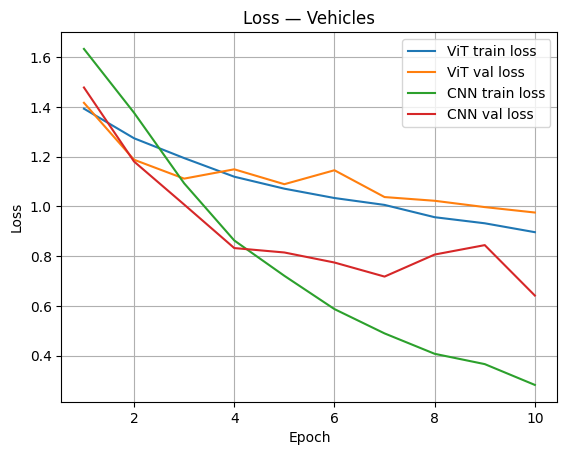

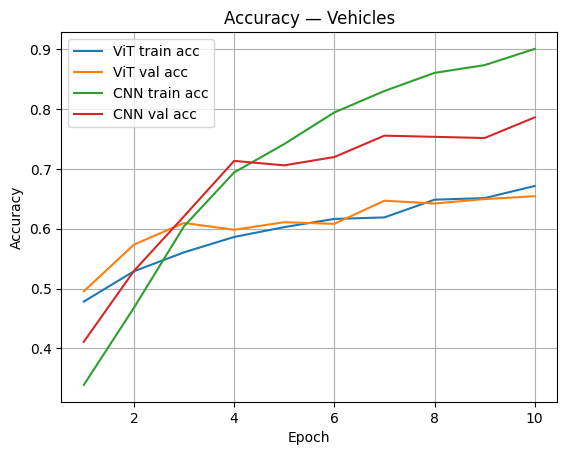

In [71]:
plot_vit_vs_cnn(results_v, title="Vehicles")

In [58]:
# Paramètres
HIDDEN_DIM = 128
NUM_HEADS = 8
PATCH_SIZE = 16 # Pour 128x128, 16 est un bon compromis

# Initialisation
vit_model_gar = VisionTransformer(
    patch_size=PATCH_SIZE, 
    hidden_dim=HIDDEN_DIM, 
    num_heads=NUM_HEADS, 
    num_layers=4, 
    num_classes=NUM_CLASSES_GAR, 
    img_size=IMG_SIZE_GAR,
    dropout=0.2
).to(device)

cnn_model_gar = VGG16CNN(num_classes=NUM_CLASSES_GAR).to(device)

# Exemple de configuration d'entraînement
optimizer_vit_gar = torch.optim.AdamW(vit_model_gar.parameters(), lr=1e-4)
optimizer_cnn_gar = torch.optim.AdamW(cnn_model_gar.parameters(), lr=1e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

print("Modèles prêts pour l'entraînement !")
print_params_report("CNN (VGG16-style)", cnn_model_gar)
print_params_report("ViT", vit_model_gar)

print_trainable_by_module(vit_model, top_k=15)
print_trainable_by_module(cnn_model, top_k=15)


Modèles prêts pour l'entraînement !
CNN (VGG16-style): trainable=33,638,218 | total=33,638,218 | trainable%=100.0%
ViT: trainable=901,258 | total=901,258 | trainable%=100.0%


In [22]:
EPOCHS = 10
results_gar = {
    "vit": {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []},
    "cnn": {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []},
}

for epoch in range(EPOCHS):
    # ---- ViT ----
    vit_train_loss, vit_train_acc = train_epoch(vit_model_gar, train_loader_gar, optimizer_vit_gar, criterion, device,desc=f"ViT train {epoch+1}/{EPOCHS}")
    vit_val_loss,   vit_val_acc   = evaluate(vit_model_gar, val_loader_gar, criterion, device,desc=f"ViT val {epoch+1}/{EPOCHS}")

    results_gar["vit"]["train_loss"].append(vit_train_loss)
    results_gar["vit"]["train_acc"].append(vit_train_acc)
    results_gar["vit"]["val_loss"].append(vit_val_loss)
    results_gar["vit"]["val_acc"].append(vit_val_acc)

    # ---- CNN ----
    cnn_train_loss, cnn_train_acc = train_epoch(cnn_model_gar, train_loader_gar, optimizer_cnn_gar, criterion, device,desc=f"CNN train {epoch+1}/{EPOCHS}")
    cnn_val_loss,   cnn_val_acc   = evaluate(cnn_model_gar, val_loader_gar, criterion, device,desc=f"CNN val {epoch+1}/{EPOCHS}")

    results_gar["cnn"]["train_loss"].append(cnn_train_loss)
    results_gar["cnn"]["train_acc"].append(cnn_train_acc)
    results_gar["cnn"]["val_loss"].append(cnn_val_loss)
    results_gar["cnn"]["val_acc"].append(cnn_val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"ViT: train acc {vit_train_acc:.2f} val acc {vit_val_acc:.2f} || "
        f"CNN: train acc {cnn_train_acc:.2f} val acc {cnn_val_acc:.2f}"
    )


Epoch 1/10 | ViT: train acc 0.41 val acc 0.42 || CNN: train acc 0.33 val acc 0.36
Epoch 2/10 | ViT: train acc 0.47 val acc 0.48 || CNN: train acc 0.42 val acc 0.43
Epoch 3/10 | ViT: train acc 0.51 val acc 0.51 || CNN: train acc 0.48 val acc 0.49
Epoch 4/10 | ViT: train acc 0.53 val acc 0.53 || CNN: train acc 0.53 val acc 0.55
Epoch 5/10 | ViT: train acc 0.55 val acc 0.56 || CNN: train acc 0.58 val acc 0.57
Epoch 6/10 | ViT: train acc 0.57 val acc 0.51 || CNN: train acc 0.63 val acc 0.63
Epoch 7/10 | ViT: train acc 0.59 val acc 0.56 || CNN: train acc 0.68 val acc 0.67
Epoch 8/10 | ViT: train acc 0.60 val acc 0.58 || CNN: train acc 0.72 val acc 0.67
Epoch 9/10 | ViT: train acc 0.61 val acc 0.56 || CNN: train acc 0.77 val acc 0.69
Epoch 10/10 | ViT: train acc 0.62 val acc 0.60 || CNN: train acc 0.82 val acc 0.69


In [23]:
torch.save(vit_model_gar.state_dict(), "10_epochs_vit_gar.pth")
torch.save(cnn_model_gar.state_dict(), "10_epochs_vgg16_gar.pth")

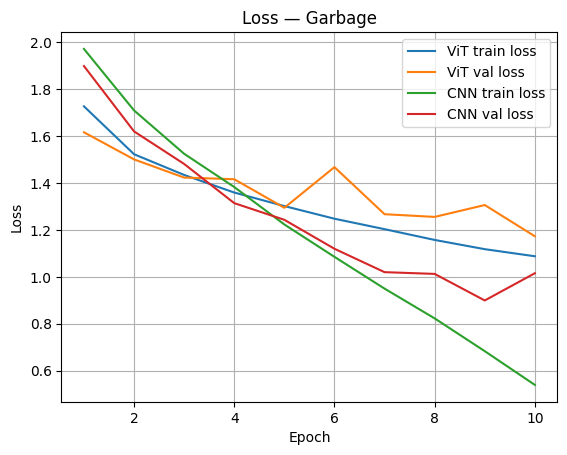

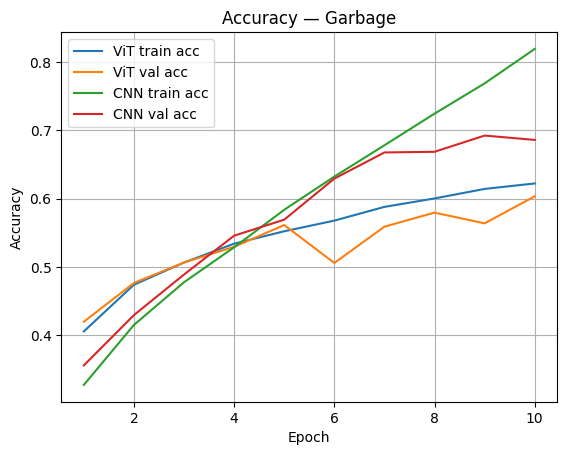

In [25]:
plot_vit_vs_cnn(results_gar, title="Garbage")

In [60]:

# Initialisation
HIDDEN_DIM = 128
NUM_HEADS = 4
PATCH_SIZE_CIF=4
NUM_CLASSES_CIF=10
vit_model_cif = VisionTransformer(
    patch_size=PATCH_SIZE_CIF, 
    hidden_dim=HIDDEN_DIM, 
    num_heads=NUM_HEADS, 
    num_layers=4, 
    num_classes=NUM_CLASSES_CIF, 
    img_size=IMG_SIZE_CIF,
    dropout=0.2
).to(device)

cnn_model_cif = VGG16CNN(num_classes=NUM_CLASSES_CIF).to(device)

# Exemple de configuration d'entraînement
optimizer_vit_cif = torch.optim.AdamW(vit_model_cif.parameters(), lr=1e-4)
optimizer_cnn_cif = torch.optim.AdamW(cnn_model_cif.parameters(), lr=1e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()
print_params_report("CNN (VGG16-style)", cnn_model_cif)
print_params_report("ViT", vit_model_cif)

print("Modèles prêts pour l'entraînement !")

CNN (VGG16-style): trainable=33,638,218 | total=33,638,218 | trainable%=100.0%
ViT: trainable=809,098 | total=809,098 | trainable%=100.0%
Modèles prêts pour l'entraînement !


In [38]:
from tqdm.auto import tqdm

EPOCHS = 10
results_cif = {
    "vit": {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []},
    "cnn": {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []},
}

for epoch in range(EPOCHS):
    # ---- ViT ----
    vit_train_loss, vit_train_acc = train_epoch(
        vit_model_cif, train_loader_cif, optimizer_vit_cif, criterion, device,
        desc=f"ViT train {epoch+1}/{EPOCHS}"
    )
    vit_val_loss, vit_val_acc = evaluate(
        vit_model_cif, val_loader_cif, criterion, device,
        desc=f"ViT val   {epoch+1}/{EPOCHS}"
    )

    results_cif["vit"]["train_loss"].append(vit_train_loss)
    results_cif["vit"]["train_acc"].append(vit_train_acc)
    results_cif["vit"]["val_loss"].append(vit_val_loss)
    results_cif["vit"]["val_acc"].append(vit_val_acc)

    # ---- CNN ----
    cnn_train_loss, cnn_train_acc = train_epoch(
        cnn_model_cif, train_loader_cif, optimizer_cnn_cif, criterion, device,
        desc=f"CNN train {epoch+1}/{EPOCHS}"
    )
    cnn_val_loss, cnn_val_acc = evaluate(
        cnn_model_cif, val_loader_cif, criterion, device,
        desc=f"CNN val   {epoch+1}/{EPOCHS}"
    )

    results_cif["cnn"]["train_loss"].append(cnn_train_loss)
    results_cif["cnn"]["train_acc"].append(cnn_train_acc)
    results_cif["cnn"]["val_loss"].append(cnn_val_loss)
    results_cif["cnn"]["val_acc"].append(cnn_val_acc)

    # ---- Affichage propre fin d'epoch ----
    tqdm.write(
        f"Epoch {epoch+1}/{EPOCHS}\n"
        f"  ViT | train: loss {vit_train_loss:.4f} acc {vit_train_acc:.3f}  "
        f"| val: loss {vit_val_loss:.4f} acc {vit_val_acc:.3f}\n"
        f"  CNN | train: loss {cnn_train_loss:.4f} acc {cnn_train_acc:.3f}  "
        f"| val: loss {cnn_val_loss:.4f} acc {cnn_val_acc:.3f}\n"
    )



ViT train 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

ViT val   1/10:   0%|          | 0/250 [00:00<?, ?it/s]

CNN train 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

CNN val   1/10:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1/10
  ViT | train: loss 0.9128 acc 0.672  | val: loss 0.9828 acc 0.647
  CNN | train: loss 0.3304 acc 0.889  | val: loss 0.7419 acc 0.789



...

ViT train 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

ViT val   10/10:   0%|          | 0/250 [00:00<?, ?it/s]

CNN train 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

CNN val   10/10:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 10/10
  ViT | train: loss 0.7526 acc 0.728  | val: loss 0.9641 acc 0.674
  CNN | train: loss 0.0982 acc 0.969  | val: loss 0.8902 acc 0.806



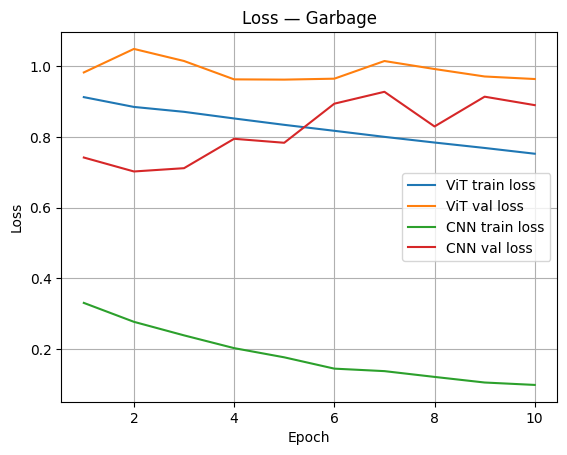

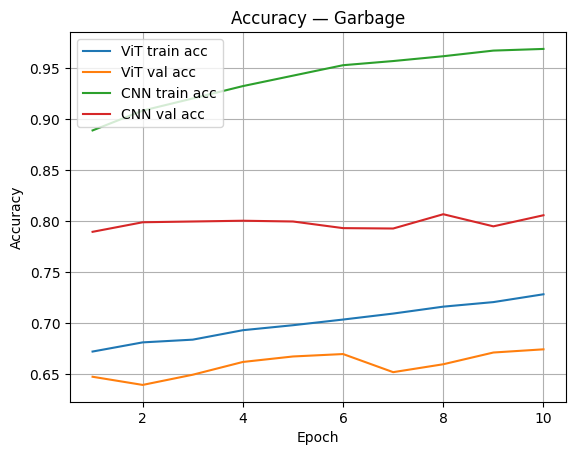

In [39]:
plot_vit_vs_cnn(results_cif, title="Garbage")